Perform PCA and Clusteringtask on Titanic Dataset.

In [6]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

df = sns.load_dataset("titanic")

X = df[['age', 'fare', 'sibsp', 'parch', 'pclass']]
y = df['survived']

X = SimpleImputer(strategy='median').fit_transform(X)
X = StandardScaler().fit_transform(X)

In [7]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print("Silhouette Score:", silhouette_score(X, labels))
print("ARI:", adjusted_rand_score(y, labels))
print("NMI:", normalized_mutual_info_score(y, labels))

Silhouette Score: 0.3757595735833647
ARI: 0.10232359621478736
NMI: 0.055647156338347784


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance:", pca.explained_variance_ratio_.sum())

Explained Variance: [0.33960812 0.32520788]
Total Variance: 0.6648159969553271


In [10]:
kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

print("PCA Silhouette Score:", silhouette_score(X_pca, labels_pca))
print("PCA ARI:", adjusted_rand_score(y, labels_pca))
print("PCA NMI:", normalized_mutual_info_score(y, labels_pca))

PCA Silhouette Score: 0.47360522533611504
PCA ARI: 0.09967574922344843
PCA NMI: 0.05381458067799029


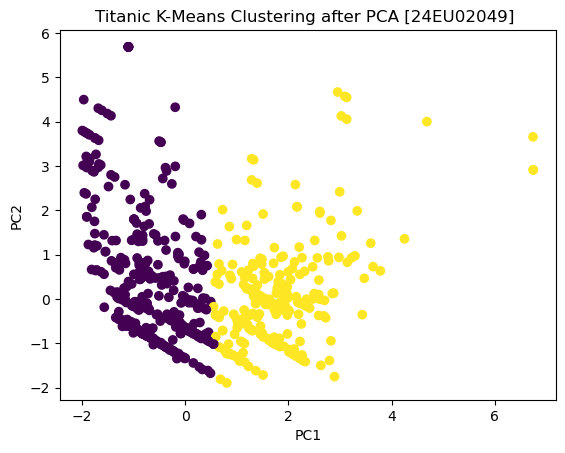

In [12]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Titanic K-Means Clustering after PCA [24EU02049] ")
plt.show()

In [13]:
result = pd.DataFrame({
    "Method": ["Raw Data", "PCA"],
    "Silhouette": [
        silhouette_score(X, labels),
        silhouette_score(X_pca, labels_pca)
    ],
    "ARI": [
        adjusted_rand_score(y, labels),
        adjusted_rand_score(y, labels_pca)
    ],
    "NMI": [
        normalized_mutual_info_score(y, labels),
        normalized_mutual_info_score(y, labels_pca)
    ]
})

print(result.round(4))

     Method  Silhouette     ARI     NMI
0  Raw Data      0.3758  0.1023  0.0556
1       PCA      0.4736  0.0997  0.0538
